# Explicabilidad del Modelo

En este notebook analizo el comportamiento interno del modelo de pronóstico de demanda desarrollado anteriormente en el proyecto.

El objetivo es comprender **qué características impulsan las predicciones de demanda de las clínicas veterinarias** y cómo estas variables influyen en los resultados del modelo.

Se utilizan dos enfoques complementarios:

• **Importancia de Características de Random Forest** — proporciona una clasificación global rápida de las características más influyentes.

• **SHAP (Shapley Additive Explanations)** — ofrece explicaciones detalladas de cómo cada característica contribuye a las predicciones.

Estas técnicas ayudan a traducir las predicciones de machine learning en **insights operativos accionables**.

In [1]:
"""
Configuración del Entorno
"""

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import shap

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)

# configuración de guardado de gráficos
NOTEBOOK_ID = "06_model_explainability"

FIGURES_DIR = Path("../figures")

def save_plot(name):
    folder = FIGURES_DIR / NOTEBOOK_ID
    folder.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        folder / f"{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Entorno listo.")

Entorno listo.


In [2]:
"""
Cargar Dataset
"""

DATA_PATH = "../data/"

df = pd.read_csv(DATA_PATH + "demand_forecasting_features.csv")

df["visit_date"] = pd.to_datetime(df["visit_date"])

df.head()

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,rolling_30d_visits_std,rolling_7d_revenue_mean,rolling_30d_revenue_mean,demand_trend_7d
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
features = [

    "lag_1_visits",
    "lag_7_visits",
    "lag_14_visits",
    "lag_30_visits",

    "rolling_7d_visits_mean",
    "rolling_30d_visits_mean",

    "rolling_7d_visits_std",

    "demand_trend_7d",

    "day_of_week",
    "month",
    "is_weekend"

]

df_model = df.dropna()

X = df_model[features]

y = df_model["daily_visits"]

print("Dataset listo:", X.shape)

Dataset listo: (89417, 11)


## Comprendiendo el Comportamiento del Modelo

Aunque los modelos predictivos pueden proporcionar pronósticos precisos, comprender los mecanismos detrás de esas predicciones es igualmente importante.

En entornos operativos como las redes de clínicas veterinarias, los responsables de la toma de decisiones suelen necesitar transparencia sobre cómo los modelos predictivos generan sus resultados.

Por esta razón, esta sección se centra en interpretar el modelo de pronóstico de demanda desarrollado anteriormente en el proyecto.

Al aplicar técnicas de explicabilidad, busco identificar los factores clave que influyen en la demanda veterinaria y comprender cómo estas variables moldean las predicciones del modelo.

In [4]:
"""
Entrenar Modelo para Explicabilidad
"""

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

print("Modelo entrenado.")

Modelo entrenado.


### Interpretación de la importancia de variables

El análisis de importancia de variables muestra que los patrones
recientes de demanda son los principales factores que influyen
en la predicción del número de visitas.

Variables como **lag_1_visits** y **rolling_7d_visits_mean**
capturan la persistencia de la demanda a corto plazo, lo que
indica que el volumen reciente de visitas es un fuerte predictor
de la demanda futura.

Las variables temporales, como **day_of_week**, también
contribuyen al modelo, sugiriendo que existen patrones
de comportamiento en cómo los clientes programan las visitas
a lo largo de la semana.

In [5]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

rolling_30d_visits_mean    0.647214
rolling_7d_visits_std      0.059304
demand_trend_7d            0.051017
day_of_week                0.048858
lag_30_visits              0.034283
lag_14_visits              0.034193
lag_1_visits               0.032941
lag_7_visits               0.032429
month                      0.031810
rolling_7d_visits_mean     0.026525
is_weekend                 0.001425
dtype: float64

La siguiente visualización muestra la importancia relativa de cada característica en el modelo de pronóstico.

Valores de importancia más altos indican que la variable tiene un papel más fuerte en la determinación de las predicciones del modelo.

Comprender estas relaciones ayuda a revelar los factores operativos más estrechamente asociados con la demanda en las clínicas veterinarias.

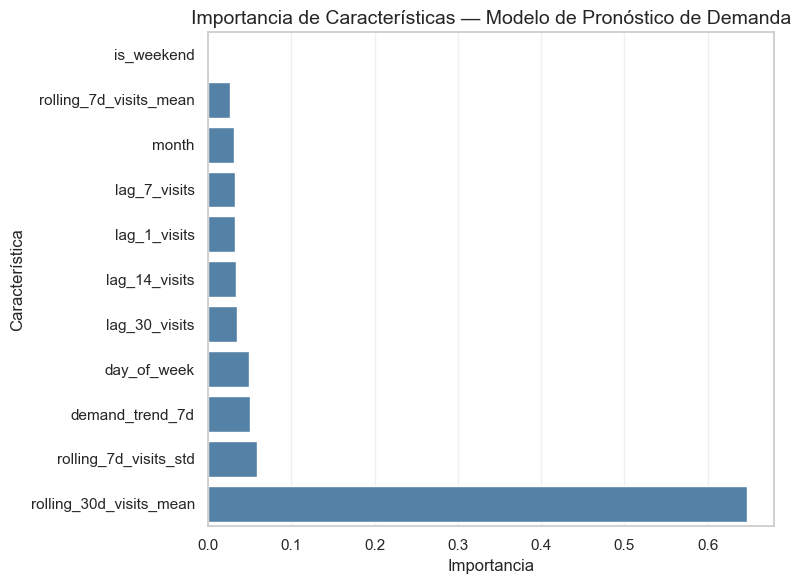

In [6]:
importance_sorted = importance.sort_values(ascending=True)

plt.figure(figsize=(8,6))

sns.barplot(
    x=importance_sorted.values,
    y=importance_sorted.index,
    color="steelblue"
)

plt.title("Importancia de Características — Modelo de Pronóstico de Demanda")

plt.xlabel("Importancia")
plt.ylabel("Característica")

plt.grid(axis="x", alpha=0.3)

save_plot("rf_feature_importance")

plt.tight_layout()

plt.show()

In [7]:
"""
Verificación del Desempeño del Modelo
"""

pred = model.predict(X)

mae = mean_absolute_error(y, pred)

rmse = np.sqrt(mean_squared_error(y, pred))

r2 = r2_score(y, pred)

print("Desempeño del Modelo")

print("MAE:", round(mae,2))

print("RMSE:", round(rmse,2))

print("R²:", round(r2,3))

Desempeño del Modelo
MAE: 0.84
RMSE: 1.08
R²: 0.95


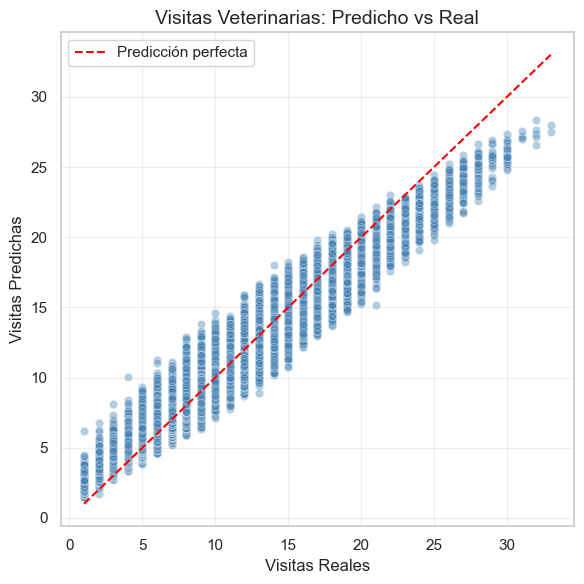

In [8]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y,
    y=pred,
    alpha=0.4,
    color="steelblue"
)

# linha de previsão perfeita
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--",
    color="red",
    label="Predicción perfecta"
)

plt.title("Visitas Veterinarias: Predicho vs Real")

plt.xlabel("Visitas Reales")
plt.ylabel("Visitas Predichas")

plt.legend()

plt.grid(alpha=0.3)

save_plot("predicted_vs_actual_explainability")

plt.tight_layout()

plt.show()

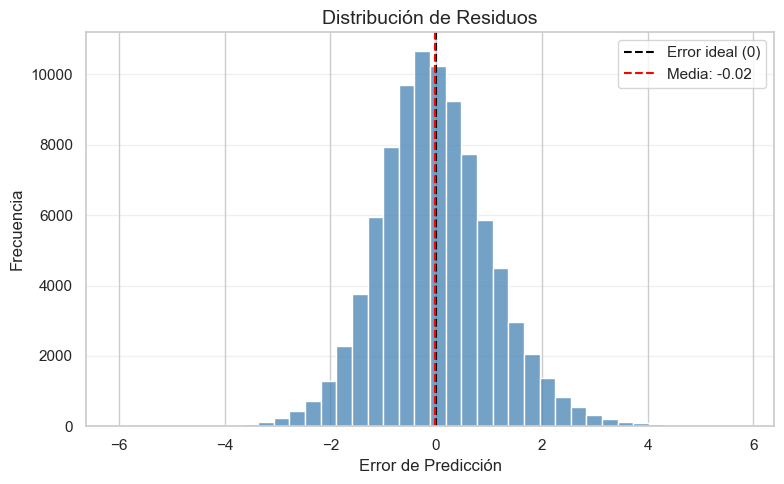

In [9]:
residuals = y - pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=40,
    color="steelblue"
)

mean_res = residuals.mean()

plt.axvline(
    0,
    linestyle="--",
    color="black",
    label="Error ideal (0)"
)

plt.axvline(
    mean_res,
    linestyle="--",
    color="red",
    label=f"Media: {mean_res:.2f}"
)

plt.title("Distribución de Residuos")

plt.xlabel("Error de Predicción")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("residual_distribution_explainability")

plt.tight_layout()

plt.show()

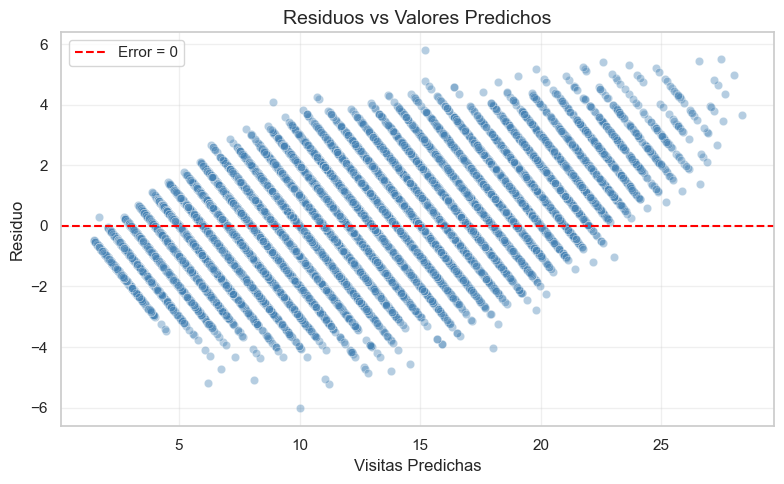

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=pred,
    y=residuals,
    alpha=0.4,
    color="steelblue"
)

plt.axhline(
    0,
    linestyle="--",
    color="red",
    label="Error = 0"
)

plt.title("Residuos vs Valores Predichos")

plt.xlabel("Visitas Predichas")
plt.ylabel("Residuo")

plt.legend()

plt.grid(alpha=0.3)

save_plot("residuals_vs_predictions_explainability")

plt.tight_layout()

plt.show()

## Explicabilidad con SHAP

Aunque la importancia de características proporciona una visión global útil, no captura completamente cómo las características individuales influyen en las predicciones.

Para obtener una interpretación más detallada, aplico SHAP (Shapley Additive Explanations), una técnica derivada de la teoría de juegos cooperativos.

Los valores SHAP asignan a cada característica un valor de contribución que cuantifica cuánto esa variable aumenta o disminuye la demanda predicha.

Este enfoque nos permite analizar tanto:

• el comportamiento global del modelo  
• explicaciones de predicciones individuales

In [11]:
"""
Muestra del Dataset para SHAP
"""

sample_size = min(200, len(X))

X_sample = X.sample(sample_size, random_state=42)

print("Tamaño de la muestra para SHAP:", X_sample.shape)

Tamaño de la muestra para SHAP: (200, 11)


In [12]:
"""
Crear Explicador SHAP
"""

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

print("Valores SHAP calculados.")

Valores SHAP calculados.


## Impacto Global de las Características

El gráfico resumen de SHAP proporciona una visión integral de cómo cada característica influye en las predicciones del modelo.

Cada punto en la visualización representa una observación individual del dataset.

La posición horizontal refleja la magnitud del valor SHAP, indicando qué tan fuertemente esa característica contribuye a aumentar o disminuir la demanda predicha.

En conjunto, estos patrones proporcionan información valiosa sobre la estructura de la demanda en las clínicas veterinarias.

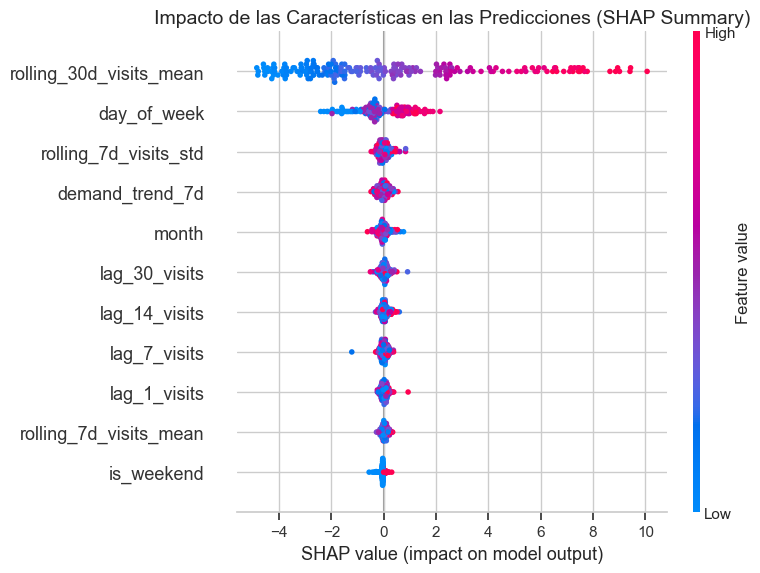

In [13]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.title("Impacto de las Características en las Predicciones (SHAP Summary)")

save_plot("shap_summary_beeswarm")

plt.tight_layout()

plt.show()

### Interpretación del análisis SHAP

El gráfico de resumen SHAP permite comprender cómo cada variable influye en las predicciones del modelo de demanda. Las variables están ordenadas según su importancia global, es decir, según su contribución promedio al resultado del modelo.

El análisis muestra que la variable más influyente es **`rolling_30d_visits_mean`**, que representa la media de visitas registradas en los últimos 30 días. Cuando este valor es alto, el modelo tiende a predecir un mayor número de visitas futuras. Este comportamiento refleja una **fuerte persistencia temporal en la demanda**, donde los niveles recientes de actividad clínica son un indicador relevante del comportamiento futuro.

La variable **`day_of_week`** también aparece entre los factores más relevantes, lo que indica que la demanda presenta **patrones semanales**. Esto sugiere que ciertos días concentran mayor actividad clínica que otros, un comportamiento común en sistemas de servicios de salud.

Otras variables importantes incluyen **`rolling_7d_visits_std`** y **`demand_trend_7d`**, que capturan la volatilidad y la tendencia reciente de la demanda. Estas variables permiten al modelo detectar cambios recientes en la actividad clínica y ajustar sus predicciones en consecuencia.

Las variables de rezago como **`lag_1_visits`**, **`lag_7_visits`**, **`lag_14_visits`** y **`lag_30_visits`** también contribuyen a la predicción, aunque su impacto es menor que el de las variables agregadas como las medias móviles. Esto sugiere que el modelo se beneficia más de capturar **tendencias recientes** que de depender de valores individuales de días específicos.

Finalmente, variables temporales como **`month`** y **`is_weekend`** tienen un impacto más reducido, lo que indica que los patrones de demanda están más influenciados por el comportamiento reciente de las visitas que por factores estrictamente estacionales.

En conjunto, el análisis SHAP confirma que **la dinámica temporal de la demanda es el principal motor de las predicciones del modelo**, destacando la importancia de las tendencias recientes y los patrones semanales en el comportamiento de las visitas a las clínicas veterinarias.

In [14]:
mean_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.Series(
    mean_shap,
    index=X_sample.columns
).sort_values(ascending=False)

shap_importance

rolling_30d_visits_mean    3.031600
day_of_week                0.733259
rolling_7d_visits_std      0.157822
demand_trend_7d            0.146774
month                      0.142726
lag_30_visits              0.110299
lag_14_visits              0.099608
lag_7_visits               0.098531
lag_1_visits               0.090529
rolling_7d_visits_mean     0.081823
is_weekend                 0.069547
dtype: float64

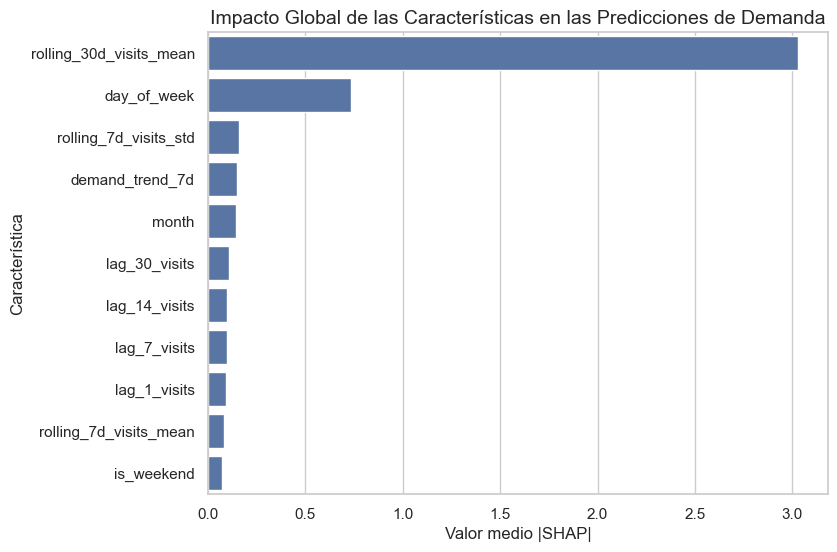

In [15]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=shap_importance.values,
    y=shap_importance.index
)

plt.title("Impacto Global de las Características en las Predicciones de Demanda")

plt.xlabel("Valor medio |SHAP|")

plt.ylabel("Característica")

plt.show()

## Principales Impulsores de la Demanda Veterinaria

El análisis de explicabilidad del modelo mediante SHAP permite identificar qué factores influyen con mayor fuerza en las predicciones de demanda de visitas veterinarias.

Los resultados revelan que la demanda está principalmente impulsada por dinámicas temporales relacionadas con la actividad reciente de las clínicas.

### Persistencia de la Demanda Reciente

La variable con mayor impacto en las predicciones es **`rolling_30d_visits_mean`**, que representa la media de visitas registradas durante los últimos 30 días.  

El comportamiento observado indica que cuando los niveles recientes de actividad clínica son altos, el modelo tiende a predecir un mayor volumen de visitas futuras.  

Este patrón refleja una **fuerte persistencia temporal en la demanda**, donde la actividad reciente actúa como un indicador clave del comportamiento futuro.

---

### Tendencias y Variabilidad de Corto Plazo

Variables como **`rolling_7d_visits_std`** y **`demand_trend_7d`** capturan cambios recientes en el comportamiento de la demanda.

Estas variables permiten al modelo detectar periodos en los que la actividad clínica está aumentando, disminuyendo o mostrando mayor volatilidad.  

En conjunto, estas métricas ayudan al modelo a adaptarse rápidamente a cambios recientes en los patrones de visitas.

---

### Patrones Temporales en el Comportamiento de los Clientes

La variable **`day_of_week`** aparece entre los factores más relevantes, lo que indica que la demanda presenta **patrones semanales claros**.

Esto sugiere que los propietarios de mascotas tienden a programar las visitas veterinarias siguiendo ciclos regulares a lo largo de la semana, generando picos y caídas previsibles en la actividad de las clínicas.

Las variables relacionadas con el calendario, como **`month`** y **`is_weekend`**, tienen un impacto menor, lo que indica que la demanda está más influenciada por patrones recientes de actividad que por una estacionalidad anual marcada.

---

### Conclusión del Análisis de Explicabilidad

En conjunto, el análisis SHAP muestra que la demanda de servicios veterinarios está fuertemente impulsada por **la dinámica reciente de visitas y por patrones temporales de corto plazo**.

Esto confirma que los modelos de machine learning pueden capturar eficazmente la estructura temporal de la demanda, utilizando información histórica para anticipar los niveles futuros de actividad en la red de clínicas veterinarias.

## Interpretación Operativa

El análisis de explicabilidad proporciona información valiosa sobre los factores que influyen en la demanda de servicios veterinarios y permite traducir los resultados del modelo en implicaciones operativas para la red de clínicas.

En primer lugar, los resultados muestran que **los niveles recientes de demanda son el principal determinante del volumen futuro de visitas**. La fuerte influencia de variables como las medias móviles de visitas indica que la actividad clínica presenta una clara persistencia temporal. Desde una perspectiva operativa, esto sugiere que el monitoreo continuo de la demanda reciente puede ser una herramienta eficaz para anticipar periodos de mayor actividad.

En segundo lugar, las variables que capturan **tendencias y variabilidad de corto plazo** permiten al modelo detectar cambios recientes en el comportamiento de los pacientes. Esto resulta especialmente útil para identificar periodos en los que la demanda está aumentando o disminuyendo, facilitando una planificación más flexible de los recursos clínicos.

Además, las variables temporales relacionadas con el **día de la semana** revelan patrones regulares en la programación de citas por parte de los propietarios de mascotas. Este tipo de patrones semanales puede utilizarse para optimizar la asignación de personal y mejorar la gestión de agendas en las clínicas.

En conjunto, estos resultados indican que la demanda veterinaria está impulsada principalmente por **patrones temporales recientes y ciclos semanales de actividad**, lo que confirma que los modelos de machine learning pueden capturar eficazmente la dinámica operativa de la red de clínicas.